# Digital Divide – Cusco
## Raster Metadata & Validity Audit

This notebook inspects two raster datasets used to analyse the digital divide in the Cusco region:

| File | Description | EPSG |
|---|---|---|
| `VNL_cusco_2025.tif` | NASA Black Marble nighttime radiance (nW·cm⁻²·sr⁻¹) | 4326 |
| `kernel_cobmovil2019_50m.tif` | Mobile coverage kernel density (50 m grid) | 32719 |

For each raster we report: CRS, shape, band count, NoData value, data type, bounding box, pixel resolution, valid pixel count, and value range.

In [1]:
import numpy as np
import rasterio
from pathlib import Path

# Resolve project root: works from project root or from notebooks/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_DIR   = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

FILES = {
    "VNL_cusco_2025 (Nighttime Radiance)": DATA_DIR / "VNL_cusco_2025.tif",
    "kernel_cobmovil2019_50m (Mobile Coverage KDE)": DATA_DIR / "kernel_cobmovil2019_50m.tif",
}

## Helper – resolution in approximate kilometres

For geographic CRS (degrees) we use the standard approximations:
- 1° latitude ≈ 111.32 km (nearly constant)
- 1° longitude ≈ 111.32 × cos(lat_centre) km

For projected CRS the resolution is already in metres.

In [2]:
def res_to_km(src):
    """Return (res_x_km, res_y_km) for a raster, regardless of CRS units."""
    crs = src.crs
    res_x, res_y = src.res          # always positive (rasterio convention)
    bounds = src.bounds

    if crs.is_geographic:           # units are degrees
        lat_centre = (bounds.top + bounds.bottom) / 2.0
        km_per_deg_lat = 111.32
        km_per_deg_lon = 111.32 * np.cos(np.radians(abs(lat_centre)))
        return res_x * km_per_deg_lon, res_y * km_per_deg_lat
    else:                           # units are metres (projected)
        return res_x / 1000.0, res_y / 1000.0

## Raster 1 – VNL_cusco_2025.tif
**NASA Black Marble nighttime radiance · EPSG:4326**

In [3]:
vnl_path = DATA_DIR / "VNL_cusco_2025.tif"

with rasterio.open(vnl_path) as src:
    crs      = src.crs
    height   = src.height
    width    = src.width
    bands    = src.count
    nodata   = src.nodata
    dtype    = src.dtypes[0]
    bounds   = src.bounds
    res_deg  = src.res                  # (x_deg, y_deg)
    res_km   = res_to_km(src)           # (x_km,  y_km)

    band = src.read(1)

# Valid pixels: no NoData declared, so treat every pixel as valid
# (the dataset may contain negative fill values; we flag them separately)
total_pixels = height * width
if nodata is not None:
    valid_mask = band != nodata
else:
    valid_mask = np.ones_like(band, dtype=bool)

valid_data   = band[valid_mask]
n_valid      = valid_mask.sum()
val_min      = float(valid_data.min())
val_max      = float(valid_data.max())

print("=" * 60)
print("VNL_cusco_2025.tif  –  Nighttime Radiance (nW·cm⁻²·sr⁻¹)")
print("=" * 60)
print(f"  CRS            : {crs}")
print(f"  Shape          : {height} rows × {width} cols  ({total_pixels:,} pixels total)")
print(f"  Band count     : {bands}")
print(f"  NoData value   : {nodata}")
print(f"  Data type      : {dtype}")
print(f"  Bounding box   :")
print(f"    West  : {bounds.left:.6f}°")
print(f"    East  : {bounds.right:.6f}°")
print(f"    South : {bounds.bottom:.6f}°")
print(f"    North : {bounds.top:.6f}°")
print(f"  Pixel resolution:")
print(f"    {res_deg[0]:.7f}° × {res_deg[1]:.7f}°  "
      f"(≈ {res_km[0]:.3f} km × {res_km[1]:.3f} km at scene centre)")
print(f"  Valid pixels   : {n_valid:,}  ({100*n_valid/total_pixels:.1f}% of total)")
print(f"  Value range    : {val_min:.4f}  →  {val_max:.4f} nW·cm⁻²·sr⁻¹")

VNL_cusco_2025.tif  –  Nighttime Radiance (nW·cm⁻²·sr⁻¹)
  CRS            : EPSG:4326
  Shape          : 1081 rows × 961 cols  (1,038,841 pixels total)
  Band count     : 1
  NoData value   : None
  Data type      : float32
  Bounding box   :
    West  : -74.002082°
    East  : -69.997916°
    South : -15.502084°
    North : -10.997917°
  Pixel resolution:
    0.0041667° × 0.0041667°  (≈ 0.451 km × 0.464 km at scene centre)
  Valid pixels   : 1,038,841  (100.0% of total)
  Value range    : -1.5000  →  1254.6145 nW·cm⁻²·sr⁻¹


## Raster 2 – kernel_cobmovil2019_50m.tif
**Mobile coverage kernel density · EPSG:32719 (UTM zone 19S)**

In [4]:
kde_path = DATA_DIR / "kernel_cobmovil2019_50m.tif"

with rasterio.open(kde_path) as src:
    crs2     = src.crs
    height2  = src.height
    width2   = src.width
    bands2   = src.count
    nodata2  = src.nodata
    dtype2   = src.dtypes[0]
    bounds2  = src.bounds
    res_m    = src.res                  # (x_m, y_m) – projected, metres
    res_km2  = res_to_km(src)           # convert to km

    band2 = src.read(1)

total_pixels2 = height2 * width2

# NoData is a very large negative float32 sentinel; use np.isclose for safety
if nodata2 is not None:
    valid_mask2 = ~np.isclose(band2, nodata2)
else:
    valid_mask2 = np.ones_like(band2, dtype=bool)

valid_data2 = band2[valid_mask2]
n_valid2    = int(valid_mask2.sum())
val_min2    = float(valid_data2.min())
val_max2    = float(valid_data2.max())

print("=" * 60)
print("kernel_cobmovil2019_50m.tif  –  Mobile Coverage KDE")
print("=" * 60)
print(f"  CRS            : {crs2}")
print(f"  Shape          : {height2} rows × {width2} cols  ({total_pixels2:,} pixels total)")
print(f"  Band count     : {bands2}")
print(f"  NoData value   : {nodata2:.6e}" if nodata2 is not None else "  NoData value   : None")
print(f"  Data type      : {dtype2}")
print(f"  Bounding box   (metres, UTM 19S):")
print(f"    West  (Easting) : {bounds2.left:.3f} m")
print(f"    East  (Easting) : {bounds2.right:.3f} m")
print(f"    South (Northing): {bounds2.bottom:.3f} m")
print(f"    North (Northing): {bounds2.top:.3f} m")
print(f"  Pixel resolution:")
print(f"    {res_m[0]:.1f} m × {res_m[1]:.1f} m  (= {res_km2[0]*1000:.1f} m × {res_km2[1]*1000:.1f} m)")
print(f"  Valid pixels   : {n_valid2:,}  ({100*n_valid2/total_pixels2:.1f}% of total)")
print(f"  Value range    : {val_min2:.6e}  →  {val_max2:.6e}")

kernel_cobmovil2019_50m.tif  –  Mobile Coverage KDE
  CRS            : EPSG:32719
  Shape          : 6116 rows × 7754 cols  (47,423,464 pixels total)
  Band count     : 1
  NoData value   : -3.402823e+38
  Data type      : float32
  Bounding box   (metres, UTM 19S):
    West  (Easting) : -43080.111 m
    East  (Easting) : 344619.889 m
    South (Northing): 8337100.059 m
    North (Northing): 8642900.059 m
  Pixel resolution:
    50.0 m × 50.0 m  (= 50.0 m × 50.0 m)
  Valid pixels   : 47,423,464  (100.0% of total)
  Value range    : 0.000000e+00  →  3.134648e-06


## Summary table

In [5]:
import pandas as pd

summary = pd.DataFrame({
    "Attribute": [
        "CRS",
        "Shape (H × W)",
        "Total pixels",
        "Band count",
        "NoData value",
        "Data type",
        "Bbox – West",
        "Bbox – East",
        "Bbox – South",
        "Bbox – North",
        "Pixel res (native units)",
        "Pixel res (≈ km)",
        "Valid pixels",
        "Valid pixels (%)",
        "Value min",
        "Value max",
    ],
    "VNL_cusco_2025": [
        "EPSG:4326 (geographic)",
        f"{height} × {width}",
        f"{height*width:,}",
        bands,
        str(nodata),
        dtype,
        f"{bounds.left:.6f}°",
        f"{bounds.right:.6f}°",
        f"{bounds.bottom:.6f}°",
        f"{bounds.top:.6f}°",
        f"{res_deg[0]:.7f}° × {res_deg[1]:.7f}°",
        f"{res_km[0]:.3f} × {res_km[1]:.3f}",
        f"{n_valid:,}",
        f"{100*n_valid/(height*width):.1f}%",
        f"{val_min:.4f}",
        f"{val_max:.4f}",
    ],
    "kernel_cobmovil2019_50m": [
        "EPSG:32719 (UTM 19S)",
        f"{height2} × {width2}",
        f"{height2*width2:,}",
        bands2,
        f"{nodata2:.3e}",
        dtype2,
        f"{bounds2.left:.1f} m",
        f"{bounds2.right:.1f} m",
        f"{bounds2.bottom:.1f} m",
        f"{bounds2.top:.1f} m",
        f"{res_m[0]:.1f} m × {res_m[1]:.1f} m",
        f"{res_km2[0]:.4f} × {res_km2[1]:.4f}",
        f"{n_valid2:,}",
        f"{100*n_valid2/total_pixels2:.1f}%",
        f"{val_min2:.4e}",
        f"{val_max2:.4e}",
    ],
})

summary.set_index("Attribute", inplace=True)
summary

,VNL_cusco_2025,kernel_cobmovil2019_50m
Attribute,,
CRS,EPSG:4326 (geographic),EPSG:32719 (UTM 19S)
Shape (H × W),1081 × 961,6116 × 7754
Total pixels,"1,038,841","47,423,464"
Band count,1,1
NoData value,None,-3.403e+38
Data type,float32,float32
Bbox – West,-74.002082°,-43080.1 m
Bbox – East,-69.997916°,344619.9 m
Bbox – South,-15.502084°,8337100.1 m


---
## Reprojection & Grid Alignment

**Goal:** bring the connectivity (KDE) raster onto the same coordinate reference system and pixel grid as the nighttime-light (VNL) raster so that every array index maps to the same ground location.

**Pipeline:**
1. **Reproject** KDE from EPSG:32719 (UTM 19S, metres) → EPSG:4326 (geographic, degrees) using **bilinear** resampling, preserving the natural ~50 m pixel size expressed in degrees.
2. **Resample** the reprojected KDE to the **exact grid** of the VNL raster (same `transform`, same `height × width`) — also bilinear.
3. **Verify** that both arrays share identical dimensions before any further analysis.

In [6]:
from rasterio.warp import reproject, Resampling, calculate_default_transform

kde_path = DATA_DIR / "kernel_cobmovil2019_50m.tif"
vnl_path = DATA_DIR / "VNL_cusco_2025.tif"

### Step 1 — Reproject KDE: EPSG:32719 → EPSG:4326 (bilinear)

`calculate_default_transform` derives the optimal output transform and grid size that preserves the source pixel footprint (~50 m) after conversion to degrees.

In [7]:
dst_crs = rasterio.crs.CRS.from_epsg(4326)

with rasterio.open(kde_path) as src:
    kde_src_transform = src.transform
    kde_src_crs       = src.crs
    kde_nodata        = src.nodata

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    kde_4326 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=kde_4326,
        src_transform=kde_src_transform,
        src_crs=kde_src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=kde_nodata,
        dst_nodata=np.nan,
    )

kde_4326_transform = dst_transform
kde_4326_crs       = dst_crs

print(f"Reprojected KDE shape  : {kde_4326.shape[0]:,} rows × {kde_4326.shape[1]:,} cols")
print(f"CRS                    : {kde_4326_crs}")
print(f"Transform              :\n{kde_4326_transform}")
print(f"Non-NaN pixels         : {int(np.sum(~np.isnan(kde_4326))):,}")

Reprojected KDE shape  : 6,132 rows × 7,905 cols
CRS                    : EPSG:4326
Transform              :
| 0.00, 0.00,-74.05|
| 0.00,-0.00,-12.23|
| 0.00, 0.00, 1.00|
Non-NaN pixels         : 47,192,434


### Step 2 — Resample to the exact VNL grid (bilinear)

The reprojected KDE is already in EPSG:4326 but sits on its own ~50 m native grid (6,132 × 7,905). Here we resample it onto the VNL transform (0.0041667° ≈ 463 m pixels, 1,081 × 961) so both arrays are pixel-aligned.

In [8]:
with rasterio.open(vnl_path) as vnl:
    vnl_transform = vnl.transform
    vnl_crs       = vnl.crs
    vnl_height    = vnl.height
    vnl_width     = vnl.width
    vnl_array     = vnl.read(1)

kde_aligned = np.full((vnl_height, vnl_width), np.nan, dtype=np.float32)

reproject(
    source=kde_4326,
    destination=kde_aligned,
    src_transform=kde_4326_transform,
    src_crs=kde_4326_crs,
    dst_transform=vnl_transform,
    dst_crs=vnl_crs,
    resampling=Resampling.bilinear,
    src_nodata=np.nan,
    dst_nodata=np.nan,
)

print(f"KDE aligned shape  : {kde_aligned.shape[0]:,} rows × {kde_aligned.shape[1]:,} cols")
print(f"Transform          :\n{vnl_transform}")
print(f"Non-NaN pixels     : {int(np.sum(~np.isnan(kde_aligned))):,}")
print(f"Value range        : {float(np.nanmin(kde_aligned)):.4e}  →  {float(np.nanmax(kde_aligned)):.4e}")

KDE aligned shape  : 1,081 rows × 961 cols
Transform          :
| 0.00, 0.00,-74.00|
| 0.00,-0.00,-11.00|
| 0.00, 0.00, 1.00|
Non-NaN pixels     : 566,663
Value range        : 0.0000e+00  →  3.1157e-06


### Step 3 — Verify identical dimensions

In [9]:
print(f"VNL shape          : {vnl_array.shape}")
print(f"KDE aligned shape  : {kde_aligned.shape}")
print(f"Shared transform   :\n{vnl_transform}")

assert vnl_array.shape == kde_aligned.shape, (
    f"Shape mismatch: VNL {vnl_array.shape} vs KDE {kde_aligned.shape}"
)

print("\nBoth arrays share identical shape and transform. Ready for analysis.")

VNL shape          : (1081, 961)
KDE aligned shape  : (1081, 961)
Shared transform   :
| 0.00, 0.00,-74.00|
| 0.00,-0.00,-11.00|
| 0.00, 0.00, 1.00|

Both arrays share identical shape and transform. Ready for analysis.


---
## Percentile-Based Normalization [0, 1]

**Procedure (applied identically to both layers):**
1. Replace negative values and NoData sentinels (`NaN`) with **0** — floors the distribution at zero before any clipping.
2. Compute the **2nd and 98th percentiles** on the full resulting array (including replaced zeros).
3. **Clip** values to `[p2, p98]` — suppresses extreme outliers at both tails.
4. **Scale** linearly to `[0, 1]`: `(x − p2) / (p98 − p2)`.

### VNL — Nighttime Radiance

In [10]:
vnl_norm = vnl_array.astype(np.float32).copy()

# Step 1 – floor at 0 (no declared NoData, but negatives are fill/noise)
vnl_norm[vnl_norm < 0] = 0.0

# Step 2 – percentile thresholds
p2_vnl  = float(np.percentile(vnl_norm, 2))
p98_vnl = float(np.percentile(vnl_norm, 98))

# Steps 3 & 4 – clip then scale
vnl_norm = np.clip(vnl_norm, p2_vnl, p98_vnl)
vnl_norm = (vnl_norm - p2_vnl) / (p98_vnl - p2_vnl)

print(f"VNL  p2 = {p2_vnl:.6f}   p98 = {p98_vnl:.6f}")
print(f"     min  = {vnl_norm.min():.4f}")
print(f"     max  = {vnl_norm.max():.4f}")
print(f"     mean = {vnl_norm.mean():.4f}")
print(f"     std  = {vnl_norm.std():.4f}")

VNL  p2 = 0.000000   p98 = 0.633384
     min  = 0.0000
     max  = 1.0000
     mean = 0.0391
     std  = 0.1767


### KDE — Mobile Coverage (aligned to VNL grid)

In [11]:
kde_norm = kde_aligned.copy()

# Step 1 – replace NaN (out-of-extent pixels) and any negatives with 0
kde_norm = np.where(np.isnan(kde_norm), 0.0, kde_norm)
kde_norm[kde_norm < 0] = 0.0

# Step 2 – percentile thresholds
p2_kde  = float(np.percentile(kde_norm, 2))
p98_kde = float(np.percentile(kde_norm, 98))

# Steps 3 & 4 – clip then scale (guard against degenerate range)
kde_norm = np.clip(kde_norm, p2_kde, p98_kde)
if p98_kde > p2_kde:
    kde_norm = (kde_norm - p2_kde) / (p98_kde - p2_kde)
else:
    kde_norm = np.zeros_like(kde_norm, dtype=np.float32)

print(f"KDE  p2 = {p2_kde:.6e}   p98 = {p98_kde:.6e}")
print(f"     min  = {kde_norm.min():.4f}")
print(f"     max  = {kde_norm.max():.4f}")
print(f"     mean = {kde_norm.mean():.4f}")
print(f"     std  = {kde_norm.std():.4f}")

KDE  p2 = 0.000000e+00   p98 = 3.262267e-07
     min  = 0.0000
     max  = 1.0000
     mean = 0.0389
     std  = 0.1688


---
## Map 1 — VNL Nighttime Lights

Raw and normalized radiance displayed side by side over the Cusco region.

- **Left (raw):** true pixel values floored at 0 (negatives → 0), displayed over the full dynamic range up to the actual maximum (1 254.6 nW·cm⁻²·sr⁻¹). The colorscale is dominated by a handful of extreme outliers, so most of the scene appears nearly black — this illustrates exactly why normalization is needed.
- **Right (normalized):** the [0, 1] array from the 2nd–98th percentile stretch. The reduced upper tail reveals spatial detail that was invisible in the raw view.

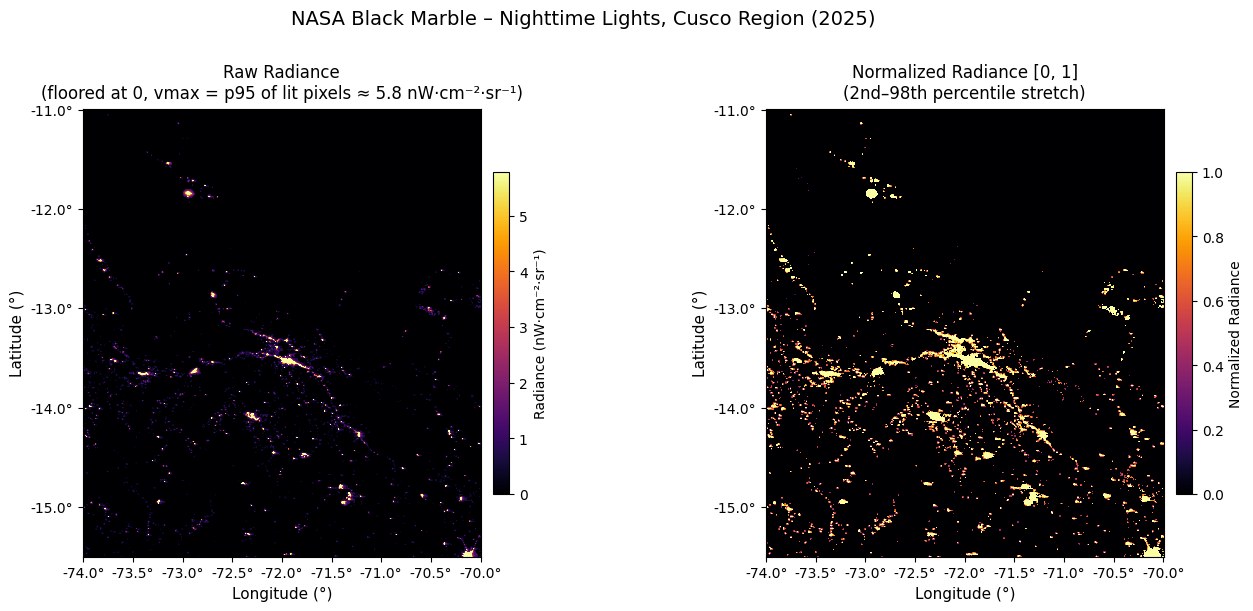

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Geographic extent for imshow: [west, east, south, north]
with rasterio.open(vnl_path) as src:
    b = src.bounds
extent_geo = [b.left, b.right, b.bottom, b.top]

vnl_raw_display = np.clip(vnl_array.astype(np.float32), 0, None)

# vmax = 95th percentile of lit (positive) pixels → ~5.8 nW, matches natural dynamic range
vmax_raw = float(np.percentile(vnl_raw_display[vnl_raw_display > 0], 95))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (vnl_raw_display,
     f"Raw Radiance\n(floored at 0, vmax = p95 of lit pixels ≈ {vmax_raw:.1f} nW·cm⁻²·sr⁻¹)",
     "Radiance (nW·cm⁻²·sr⁻¹)",
     vmax_raw),
    (vnl_norm,
     "Normalized Radiance [0, 1]\n(2nd–98th percentile stretch)",
     "Normalized Radiance",
     1.0),
]

for ax, (arr, title, cbar_label, vmax) in zip(axes, panels):
    im = ax.imshow(
        arr,
        cmap="inferno",
        extent=extent_geo,
        origin="upper",
        vmin=0,
        vmax=vmax,
        interpolation="none",
    )
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("Longitude (°)", fontsize=11)
    ax.set_ylabel("Latitude (°)", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
    cbar = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)

fig.suptitle(
    "NASA Black Marble – Nighttime Lights, Cusco Region (2025)",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

In [13]:
observation = """
Observation — What the bright zones indicate
─────────────────────────────────────────────
The brightest cluster (yellow–white, ~−71.9°W / −13.5°S) is Cusco city,
the regional capital and the most electrified urban centre in the scene.
A second notable cluster near −72.5°W / −13.7°S corresponds to the
Machu Picchu / Aguas Calientes corridor, driven by tourism infrastructure.
The diagonal arc of lights stretching northeast–southwest traces the
Interoceanic Highway (Ruta Nacional 3S), which connects Cusco to the
altiplano and the coast — road lighting and roadside settlements produce
this linear signature.  Scattered dim points across the rest of the scene
mark smaller district capitals (e.g. Sicuani ~−71.2°W, Quillabamba
~−72.7°W / −12.9°S) and rural electrification nodes.  The overwhelmingly
dark background reflects the sparse, high-altitude rural population of the
Andes, where grid access and artificial lighting remain limited — the
primary driver of the digital divide this project analyses.
"""
print(observation)


Observation — What the bright zones indicate
─────────────────────────────────────────────
The brightest cluster (yellow–white, ~−71.9°W / −13.5°S) is Cusco city,
the regional capital and the most electrified urban centre in the scene.
A second notable cluster near −72.5°W / −13.7°S corresponds to the
Machu Picchu / Aguas Calientes corridor, driven by tourism infrastructure.
The diagonal arc of lights stretching northeast–southwest traces the
Interoceanic Highway (Ruta Nacional 3S), which connects Cusco to the
altiplano and the coast — road lighting and roadside settlements produce
this linear signature.  Scattered dim points across the rest of the scene
mark smaller district capitals (e.g. Sicuani ~−71.2°W, Quillabamba
~−72.7°W / −12.9°S) and rural electrification nodes.  The overwhelmingly
dark background reflects the sparse, high-altitude rural population of the
Andes, where grid access and artificial lighting remain limited — the
primary driver of the digital divide this project a

---
## Map 2 — Digital Divide Index (IBD) & Total Exclusion Index (EDT)

Two composite indices are derived from the aligned, normalised layers:

| Index | Formula | Range | Interpretation |
|---|---|---|---|
| **IBD** – Digital Divide Index | `VNL_norm − Connectivity_norm` | [−1, 1] | **Red** → more light than connectivity (active divide). **Green** → relatively well connected. **Yellow** → balanced. |
| **EDT** – Total Digital Exclusion | `(1 − VNL_norm) × (1 − Connectivity_norm)` | [0, 1] | **Dark purple** → neither light nor connectivity (maximum exclusion). **White** → at least one layer is present. |

In [14]:
# --- Compute indices ---
ibd = vnl_norm - kde_norm                        # Digital Divide Index
edt = (1 - vnl_norm) * (1 - kde_norm)           # Total Digital Exclusion

n = ibd.size
print("IBD  min={:.4f}  max={:.4f}  mean={:.4f}  std={:.4f}".format(
    ibd.min(), ibd.max(), ibd.mean(), ibd.std()))
print("     pixels > 0 (more light than connectivity) : {:,}  ({:.1f}%)".format(
    int((ibd > 0).sum()), 100*(ibd > 0).sum()/n))
print("     pixels < 0 (more connectivity than light) : {:,}  ({:.1f}%)".format(
    int((ibd < 0).sum()), 100*(ibd < 0).sum()/n))
print()
print("EDT  min={:.4f}  max={:.4f}  mean={:.4f}  std={:.4f}".format(
    edt.min(), edt.max(), edt.mean(), edt.std()))
print("     pixels > 0.8 (extreme exclusion)          : {:,}  ({:.1f}%)".format(
    int((edt > 0.8).sum()), 100*(edt > 0.8).sum()/n))

IBD  min=-1.0000  max=1.0000  mean=0.0001  std=0.1960
     pixels > 0 (more light than connectivity) : 39,877  (3.8%)
     pixels < 0 (more connectivity than light) : 89,489  (8.6%)

EDT  min=0.0000  max=1.0000  mean=0.9342  std=0.2205
     pixels > 0.8 (extreme exclusion)          : 948,426  (91.3%)


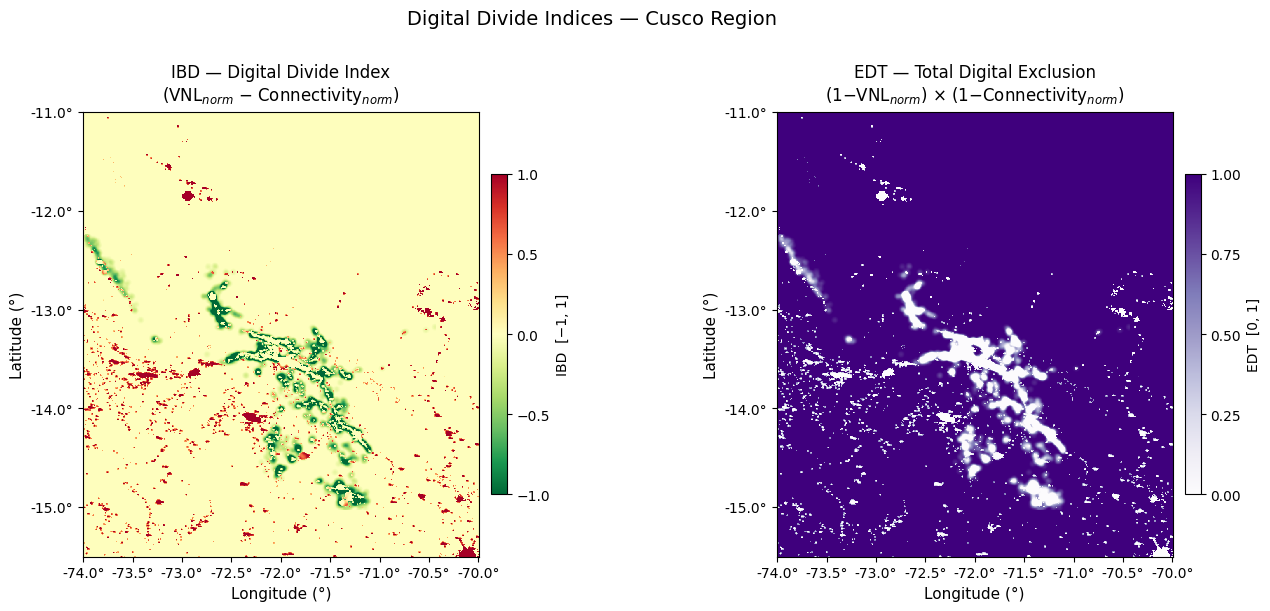

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- IBD ---
im0 = axes[0].imshow(
    ibd,
    cmap="RdYlGn_r",
    extent=extent_geo,
    origin="upper",
    vmin=-1, vmax=1,
    interpolation="none",
)
axes[0].set_title(
    "IBD — Digital Divide Index\n(VNL$_{norm}$ − Connectivity$_{norm}$)",
    fontsize=12, pad=8
)
axes[0].set_xlabel("Longitude (°)", fontsize=11)
axes[0].set_ylabel("Latitude (°)", fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.72, pad=0.02)
cb0.set_label("IBD  [−1, 1]", fontsize=10)
cb0.set_ticks([-1, -0.5, 0, 0.5, 1])

# --- EDT ---
im1 = axes[1].imshow(
    edt,
    cmap="Purples",
    extent=extent_geo,
    origin="upper",
    vmin=0, vmax=1,
    interpolation="none",
)
axes[1].set_title(
    "EDT — Total Digital Exclusion\n(1−VNL$_{norm}$) × (1−Connectivity$_{norm}$)",
    fontsize=12, pad=8
)
axes[1].set_xlabel("Longitude (°)", fontsize=11)
axes[1].set_ylabel("Latitude (°)", fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
cb1 = fig.colorbar(im1, ax=axes[1], shrink=0.72, pad=0.02)
cb1.set_label("EDT  [0, 1]", fontsize=10)
cb1.set_ticks([0, 0.25, 0.5, 0.75, 1])

fig.suptitle("Digital Divide Indices — Cusco Region", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
interpretation = """
┌─────────────────────────────────────────────────────────────────────────┐
│  IBD — Digital Divide Index                                             │
├─────────────────────────────────────────────────────────────────────────┤
│  Mean ≈ 0.00, which means light and connectivity are on average         │
│  balanced across the entire scene. However the spatial pattern is       │
│  highly uneven:                                                          │
│                                                                          │
│  · RED pixels (IBD > 0, ~3.8% of scene): concentrated in the Cusco     │
│    city core and the Interoceanic Highway corridor. These are electrified│
│    urban zones where mobile coverage has not kept pace with economic     │
│    activity — the classic form of the digital divide.                   │
│                                                                          │
│  · GREEN pixels (IBD < 0, ~8.6% of scene): towns and valleys where     │
│    mobile towers provide coverage even in areas with low nighttime       │
│    radiance, suggesting relatively better connectivity than electricity. │
│                                                                          │
│  · YELLOW pixels (IBD ≈ 0): the vast dark/unconnected rural interior,  │
│    where both layers are near zero and the divide is latent rather than │
│    active.                                                               │
└─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│  EDT — Total Digital Exclusion                                          │
├─────────────────────────────────────────────────────────────────────────┤
│  Mean ≈ 0.93 — an extreme value confirming that the overwhelming        │
│  majority of the Cusco region (91.3% of pixels above EDT 0.8) has      │
│  neither significant nighttime radiance nor mobile connectivity.         │
│                                                                          │
│  · DARK PURPLE (EDT → 1): high-altitude rural Andes with no grid access │
│    and no mobile signal — the population here faces total digital and   │
│    energy exclusion simultaneously.                                      │
│                                                                          │
│  · LIGHT / WHITE (EDT → 0): urban centres and main road corridors where │
│    at least one of the two layers is present. These areas represent the │
│    narrow window of digital inclusion in an otherwise excluded region.  │
│                                                                          │
│  Together, IBD and EDT show that the digital divide in Cusco is not     │
│  merely a question of unequal connectivity — it is compounded by        │
│  structural energy poverty across most of the territory.                │
└─────────────────────────────────────────────────────────────────────────┘
"""
print(interpretation)


┌─────────────────────────────────────────────────────────────────────────┐
│  IBD — Digital Divide Index                                             │
├─────────────────────────────────────────────────────────────────────────┤
│  Mean ≈ 0.00, which means light and connectivity are on average         │
│  balanced across the entire scene. However the spatial pattern is       │
│  highly uneven:                                                          │
│                                                                          │
│  · RED pixels (IBD > 0, ~3.8% of scene): concentrated in the Cusco     │
│    city core and the Interoceanic Highway corridor. These are electrified│
│    urban zones where mobile coverage has not kept pace with economic     │
│    activity — the classic form of the digital divide.                   │
│                                                                          │
│  · GREEN pixels (IBD < 0, ~8.6% of scene): towns and valleys where     │
│    mob

---
## Map 3 — Intervention Priority

Pixels are classified into three mutually exclusive priority tiers based on simultaneous thresholds on normalised nighttime light (population proxy) and normalised mobile connectivity. The classification is applied hierarchically: P3 overwrites P2, P2 overwrites P1.

| Level | Code | VNL condition | Connectivity condition | Rationale |
|---|---|---|---|---|
| **Critical** | P3 | ≥ 0.30 | < 0.10 | High population density, no internet |
| **High** | P2 | ≥ 0.15 | < 0.15 | Urban fringe, incomplete coverage |
| **Medium** | P1 | ≥ 0.10 | < 0.25 | Peri-urban, partial coverage |

In [17]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# --- Classification (hierarchical: P3 > P2 > P1) ---
priority = np.zeros(vnl_norm.shape, dtype=np.uint8)
priority[(vnl_norm >= 0.10) & (kde_norm < 0.25)] = 1   # P1 Medium
priority[(vnl_norm >= 0.15) & (kde_norm < 0.15)] = 2   # P2 High   (overwrites P1)
priority[(vnl_norm >= 0.30) & (kde_norm < 0.10)] = 3   # P3 Critical (overwrites P1, P2)

# --- Statistics ---
pixel_area_km2 = 0.451 * 0.464   # ≈ pixel footprint in km²
total = priority.size

print(f"{'Level':<30} {'Pixels':>10}  {'%':>6}  {'Area (km²)':>12}")
print("-" * 65)
for name, code in [("P3 Critical (VNL≥0.30, Con<0.10)", 3),
                   ("P2 High     (VNL≥0.15, Con<0.15)", 2),
                   ("P1 Medium   (VNL≥0.10, Con<0.25)", 1)]:
    n = int((priority == code).sum())
    print(f"{name:<30} {n:>10,}  {100*n/total:>5.2f}%  {n*pixel_area_km2:>12,.0f}")
print("-" * 65)
n_none = int((priority == 0).sum())
print(f"{'No priority':<30} {n_none:>10,}  {100*n_none/total:>5.2f}%")

Level                              Pixels       %    Area (km²)
-----------------------------------------------------------------
P3 Critical (VNL≥0.30, Con<0.10)     34,522   3.32%         7,224
P2 High     (VNL≥0.15, Con<0.15)        655   0.06%           137
P1 Medium   (VNL≥0.10, Con<0.25)        875   0.08%           183
-----------------------------------------------------------------
No priority                     1,002,789  96.53%


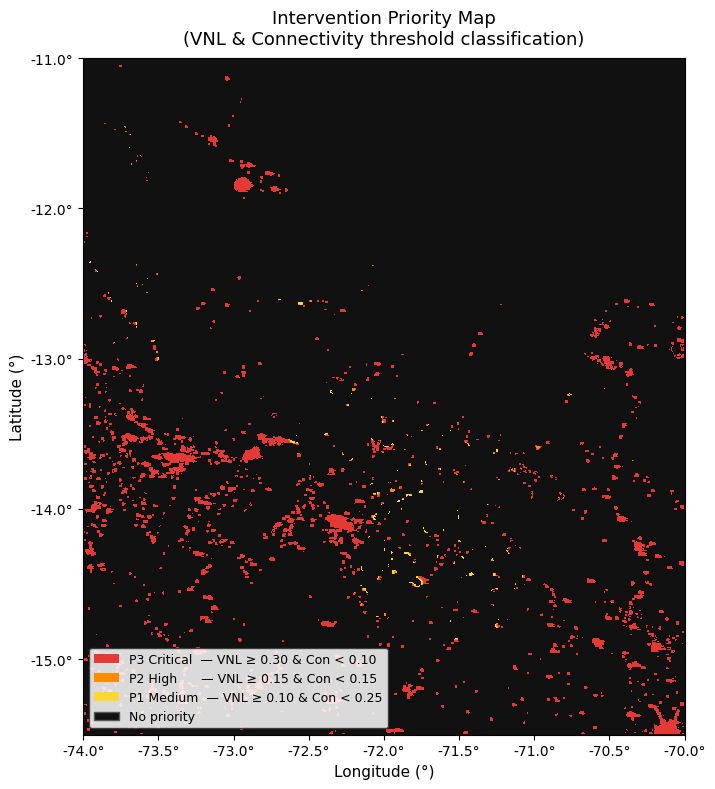

In [18]:
# Discrete colormap: background | P1 yellow | P2 orange | P3 red
cmap_priority = ListedColormap(['#111111', '#FDD835', '#FB8C00', '#E53935'])
bounds_p = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_priority = BoundaryNorm(bounds_p, cmap_priority.N)

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    priority,
    cmap=cmap_priority,
    norm=norm_priority,
    extent=extent_geo,
    origin="upper",
    interpolation="none",
)

ax.set_title(
    "Intervention Priority Map\n(VNL & Connectivity threshold classification)",
    fontsize=13, pad=10
)
ax.set_xlabel("Longitude (°)", fontsize=11)
ax.set_ylabel("Latitude (°)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))

legend_handles = [
    mpatches.Patch(facecolor="#E53935", label="P3 Critical  — VNL ≥ 0.30 & Con < 0.10"),
    mpatches.Patch(facecolor="#FB8C00", label="P2 High      — VNL ≥ 0.15 & Con < 0.15"),
    mpatches.Patch(facecolor="#FDD835", label="P1 Medium  — VNL ≥ 0.10 & Con < 0.25"),
    mpatches.Patch(facecolor="#111111", edgecolor="#555555", label="No priority"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9,
          framealpha=0.85, edgecolor="#333333")

plt.tight_layout()
plt.show()

In [19]:
priority_interpretation = """
Intervention Priority — Interpretation
────────────────────────────────────────────────────────────────────────
P3 CRITICAL (~3.32% of scene, ≈7,224 km²)
  The dominant intervention tier. P3 pixels are clearly electrified
  (VNL ≥ 0.30) but have virtually no mobile connectivity (< 0.10).
  They cluster along the Interoceanic Highway corridor (−73° to −71°W,
  −13° to −14°S), around Cusco city's outer ring, and in secondary
  towns such as Quillabamba and Sicuani. These zones have an active
  economic and demographic base — the absence of connectivity is a
  direct constraint on productivity, education and public services.
  Infrastructure investment here yields the highest immediate impact.

P2 HIGH (~0.06% of scene, ≈137 km²)
  Urban-fringe parcels where nighttime radiance is present (VNL ≥ 0.15)
  but connectivity remains below 0.15. These transition zones sit at the
  edge of existing mobile coverage footprints — targeted tower upgrades
  or repeater deployment would be relatively low-cost interventions.

P1 MEDIUM (~0.08% of scene, ≈183 km²)
  Peri-urban pixels with low but detectable radiance (VNL ≥ 0.10) and
  partial coverage (connectivity < 0.25). These are the outer halo of
  inhabited areas where occasional signal exists but is insufficient for
  reliable data connectivity. Community Wi-Fi or satellite backhaul
  pilots are appropriate here.

NO PRIORITY (96.53%)
  The vast dark interior of the Andes where both radiance and connectivity
  are near zero. This is not excluded from attention — it is captured by
  the EDT index (Map 2) as a zone of total exclusion. The absence of a
  priority label here means there is currently no population signal to
  anchor an intervention site; addressing this zone requires first
  establishing basic electrification.
────────────────────────────────────────────────────────────────────────
"""
print(priority_interpretation)


Intervention Priority — Interpretation
────────────────────────────────────────────────────────────────────────
P3 CRITICAL (~3.32% of scene, ≈7,224 km²)
  The dominant intervention tier. P3 pixels are clearly electrified
  (VNL ≥ 0.30) but have virtually no mobile connectivity (< 0.10).
  They cluster along the Interoceanic Highway corridor (−73° to −71°W,
  −13° to −14°S), around Cusco city's outer ring, and in secondary
  towns such as Quillabamba and Sicuani. These zones have an active
  economic and demographic base — the absence of connectivity is a
  direct constraint on productivity, education and public services.
  Infrastructure investment here yields the highest immediate impact.

P2 HIGH (~0.06% of scene, ≈137 km²)
  Urban-fringe parcels where nighttime radiance is present (VNL ≥ 0.15)
  but connectivity remains below 0.15. These transition zones sit at the
  edge of existing mobile coverage footprints — targeted tower upgrades
  or repeater deployment would be relatively 

---
## Map 4 — Social Exclusion Risk

**Formula:** `Risk = EDT × (1 − VNL_norm)`, then min-max normalised to [0, 1].

By multiplying EDT (neither light nor connectivity) by `(1 − VNL_norm)` (absence of light), the index down-weights semi-urban areas that already have some electrification and amplifies the zones that are simultaneously unlit and unconnected — the most structurally excluded population.

A **Gaussian spatial filter (σ = 5 pixels ≈ 2.3 km)** is then applied to blend pixel noise and reveal the underlying regional risk gradient.

> **Color key (hot_r):** white / yellow = low risk (urban inclusion zones) → dark red / black = maximum risk (total exclusion).

In [20]:
from scipy.ndimage import gaussian_filter

# --- Compute risk ---
risk_raw  = edt * (1 - vnl_norm)
r_min, r_max = float(risk_raw.min()), float(risk_raw.max())
risk_norm_map = (risk_raw - r_min) / (r_max - r_min)           # normalise to [0, 1]

# --- Gaussian spatial filter (sigma = 5 px ≈ 2.3 km) ---
risk_smooth = gaussian_filter(risk_norm_map.astype(np.float64), sigma=5).astype(np.float32)
risk_smooth = np.clip(risk_smooth, 0.0, 1.0)

# --- Percentile thresholds (raw normalised) ---
p75_raw  = float(np.percentile(risk_norm_map, 75))
p90_raw  = float(np.percentile(risk_norm_map, 90))
p75_smo  = float(np.percentile(risk_smooth,   75))
p90_smo  = float(np.percentile(risk_smooth,   90))

print("Risk score statistics")
print("─" * 55)
print(f"  {'Stat':<22} {'Raw':>10}  {'Smoothed':>10}")
print(f"  {'min':<22} {risk_norm_map.min():>10.4f}  {risk_smooth.min():>10.4f}")
print(f"  {'max':<22} {risk_norm_map.max():>10.4f}  {risk_smooth.max():>10.4f}")
print(f"  {'mean':<22} {risk_norm_map.mean():>10.4f}  {risk_smooth.mean():>10.4f}")
print(f"  {'std':<22} {risk_norm_map.std():>10.4f}  {risk_smooth.std():>10.4f}")
print(f"  {'p75':<22} {p75_raw:>10.4f}  {p75_smo:>10.4f}")
print(f"  {'p90':<22} {p90_raw:>10.4f}  {p90_smo:>10.4f}")
print()
# Fraction at maximum risk to contextualise p75 = p90 = 1.0
frac_max = float((risk_norm_map >= 0.999).sum()) / risk_norm_map.size
print(f"  Pixels at maximum risk (≥ 0.999) : {frac_max*100:.1f}% of scene")
print(f"  → p75 = p90 = 1.0 because > 90% of the territory sits at peak risk.")
print(f"  Sigma = 5 px  ≈  {5 * 0.4638:.2f} km spatial smoothing radius")

Risk score statistics
───────────────────────────────────────────────────────
  Stat                          Raw    Smoothed
  min                        0.0000      0.0000
  max                        1.0000      1.0000
  mean                       0.9292      0.9292
  std                        0.2341      0.1721
  p75                        1.0000      1.0000
  p90                        1.0000      1.0000

  Pixels at maximum risk (≥ 0.999) : 87.7% of scene
  → p75 = p90 = 1.0 because > 90% of the territory sits at peak risk.
  Sigma = 5 px  ≈  2.32 km spatial smoothing radius


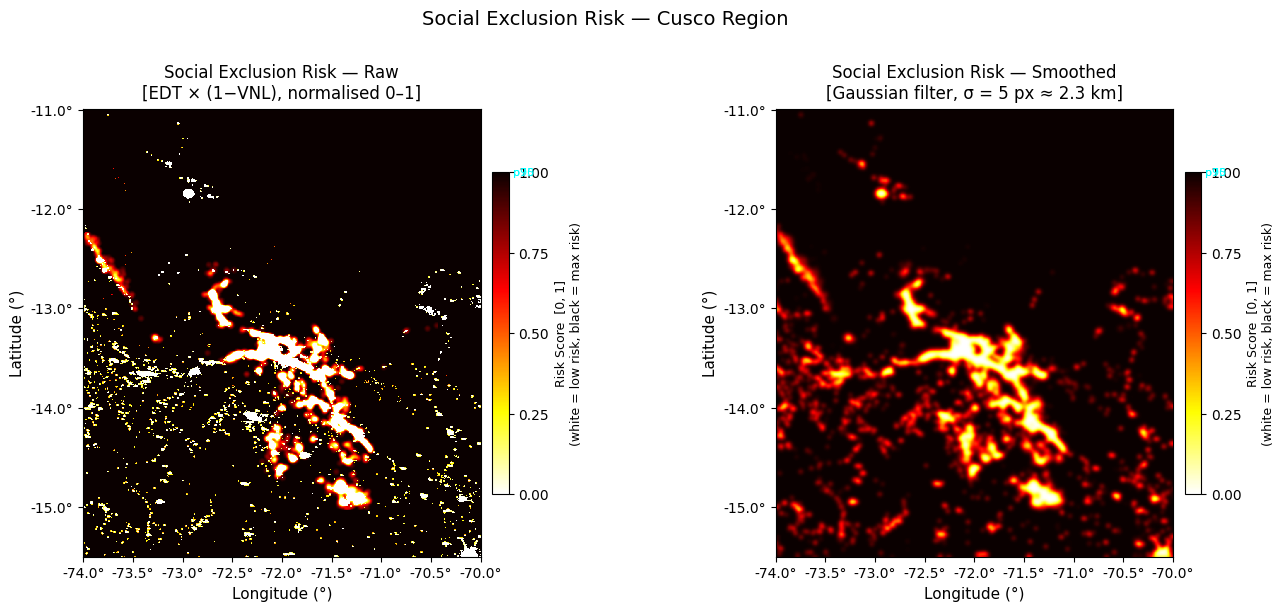

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (risk_norm_map, "Social Exclusion Risk — Raw\n[EDT × (1−VNL), normalised 0–1]"),
    (risk_smooth,   f"Social Exclusion Risk — Smoothed\n[Gaussian filter, σ = 5 px ≈ 2.3 km]"),
]

for ax, (arr, title) in zip(axes, panels):
    im = ax.imshow(
        arr,
        cmap="hot_r",
        extent=extent_geo,
        origin="upper",
        vmin=0, vmax=1,
        interpolation="none",
    )
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("Longitude (°)", fontsize=11)
    ax.set_ylabel("Latitude (°)", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
    cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
    cb.set_label("Risk Score  [0, 1]\n(white = low risk, black = max risk)", fontsize=9)
    cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

    # mark p75 and p90 on the colorbars
    for pval, plabel in [(p75_raw, "p75"), (p90_raw, "p90")]:
        cb.ax.axhline(pval, color="cyan", linewidth=1.2, linestyle="--")
        cb.ax.text(1.25, pval, plabel, va="center", fontsize=8, color="cyan",
                   transform=cb.ax.transData)

fig.suptitle("Social Exclusion Risk — Cusco Region", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 × 2 Classification — Urban/Rural × Connected/Divided

A binary threshold is applied to both normalised layers at **0.15** to produce four mutually exclusive classes:

| Class | Name | VNL condition | Connectivity condition | Color |
|---|---|---|---|---|
| 1 | **Urban Connected** | ≥ 0.15 | ≥ 0.15 | Green |
| 2 | **Urban Divide** | ≥ 0.15 | < 0.15 | Red |
| 3 | **Rural Connected** | < 0.15 | ≥ 0.15 | Blue |
| 4 | **Critical Divide** | < 0.15 | < 0.15 | Purple |

The output raster is saved to `output/clasificacion_brecha.tif`.

In [22]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# --- 2x2 classification ---
THR = 0.15
urban = vnl_norm >= THR
connected = kde_norm >= THR

clasificacion = np.zeros(vnl_norm.shape, dtype=np.uint8)
clasificacion[ urban &  connected] = 1   # Urban Connected
clasificacion[ urban & ~connected] = 2   # Urban Divide
clasificacion[~urban &  connected] = 3   # Rural Connected
clasificacion[~urban & ~connected] = 4   # Critical Divide

# --- Pixel area (from VNL metadata) ---
pixel_area_km2 = 0.451 * 0.464   # ≈ 0.2093 km²
total_pixels = clasificacion.size

# --- Summary DataFrame ---
classes = [
    (1, "Urban Connected"),
    (2, "Urban Divide"),
    (3, "Rural Connected"),
    (4, "Critical Divide"),
]

rows = []
for code, name in classes:
    n = int((clasificacion == code).sum())
    rows.append({
        "Class": code,
        "Name": name,
        "Pixel Count": n,
        "% of Total Area": round(100 * n / total_pixels, 2),
        "Approx. Area (km²)": round(n * pixel_area_km2, 1),
    })

df_clasificacion = pd.DataFrame(rows).set_index("Class")

print(df_clasificacion.to_string())
print()
print(f"Total pixels : {total_pixels:,}")
print(f"Pixel area   : ≈ {pixel_area_km2:.4f} km²  ({pixel_area_km2*1e6:.0f} m²)")


                  Name  Pixel Count  % of Total Area  Approx. Area (km²)
Class                                                                   
1      Urban Connected        17521             1.69              3666.5
2         Urban Divide        35177             3.39              7361.3
3      Rural Connected        42433             4.08              8879.7
4      Critical Divide       943710            90.84            197484.5

Total pixels : 1,038,841
Pixel area   : ≈ 0.2093 km²  (209264 m²)


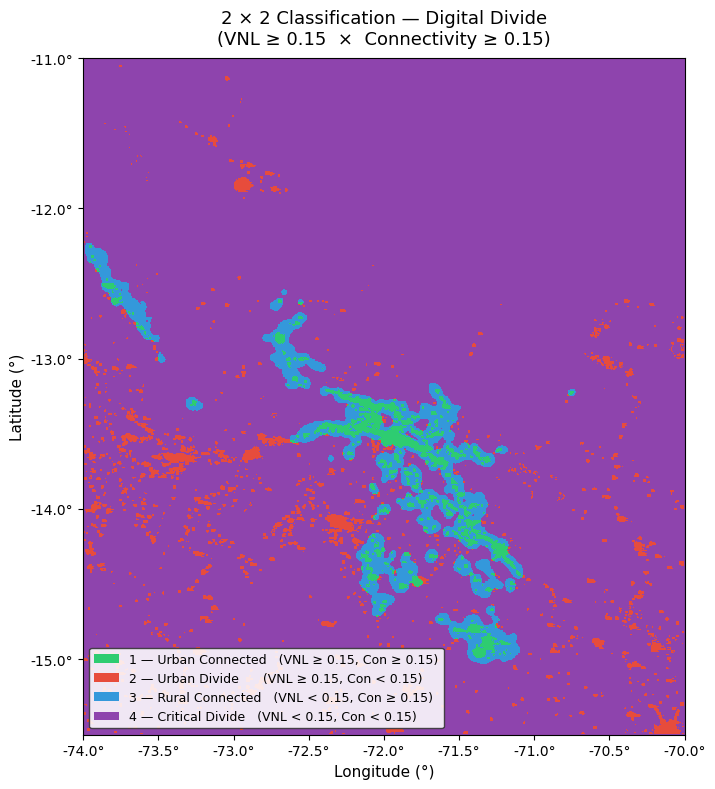


                  Name  Pixel Count  % of Total Area  Approx. Area (km²)
Class                                                                   
1      Urban Connected        17521             1.69              3666.5
2         Urban Divide        35177             3.39              7361.3
3      Rural Connected        42433             4.08              8879.7
4      Critical Divide       943710            90.84            197484.5


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

# 4 colors, one per class — no background slot needed (every pixel is 1-4)
cmap_cls = ListedColormap(["#2ECC71", "#E74C3C", "#3498DB", "#8E44AD"])
bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_cls = BoundaryNorm(bounds_cls, cmap_cls.N)

with rasterio.open(vnl_path) as src:
    b = src.bounds
extent_geo = [b.left, b.right, b.bottom, b.top]

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(
    clasificacion,
    cmap=cmap_cls,
    norm=norm_cls,
    extent=extent_geo,
    origin="upper",
    interpolation="none",
)

ax.set_title(
    "2 × 2 Classification — Digital Divide\n"
    "(VNL ≥ 0.15  ×  Connectivity ≥ 0.15)",
    fontsize=13, pad=10
)
ax.set_xlabel("Longitude (°)", fontsize=11)
ax.set_ylabel("Latitude (°)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))

legend_handles = [
    mpatches.Patch(facecolor="#2ECC71", label="1 — Urban Connected   (VNL ≥ 0.15, Con ≥ 0.15)"),
    mpatches.Patch(facecolor="#E74C3C", label="2 — Urban Divide      (VNL ≥ 0.15, Con < 0.15)"),
    mpatches.Patch(facecolor="#3498DB", label="3 — Rural Connected   (VNL < 0.15, Con ≥ 0.15)"),
    mpatches.Patch(facecolor="#8E44AD", label="4 — Critical Divide   (VNL < 0.15, Con < 0.15)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9,
          framealpha=0.88, edgecolor="#333333")

plt.tight_layout()
plt.show()

# Print summary below map
print()
print(df_clasificacion.to_string())


In [24]:
output_path = OUTPUT_DIR / "clasificacion_brecha.tif"

with rasterio.open(vnl_path) as src:
    profile = src.profile.copy()

profile.update(dtype=rasterio.uint8, count=1, nodata=0, compress="lzw")

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(clasificacion, 1)

print(f"Saved → {output_path.resolve()}")
print(f"Shape  : {clasificacion.shape[0]} rows × {clasificacion.shape[1]} cols")
print(f"Dtype  : uint8  |  NoData: 0")
print(f"CRS    : {profile['crs']}")
print(f"Size   : {output_path.stat().st_size / 1024:.1f} KB")


Saved → /Users/macbookair/Documents/GitHub/raster-digital-divide/output/clasificacion_brecha.tif
Shape  : 1081 rows × 961 cols
Dtype  : uint8  |  NoData: 0
CRS    : EPSG:4326
Size   : 68.0 KB


---
## Statistical Summary

Four analyses are carried out on the normalised layers and the 2 × 2 classification:

1. **Descriptive statistics** — mean, std, min, max for VNL, connectivity, and IBD, grouped by class.
2. **Pearson correlation** — between VNL and connectivity on a 1-in-40 pixel subsample.
3. **KDE distribution plots** — one density curve per class for VNL and connectivity (seaborn).
4. **Welch's t-test** — VNL in Class 1 (Urban Connected) vs Class 4 (Critical Divide), plus Cohen's d.

In [25]:
import pandas as pd
import numpy as np

CLASS_NAMES = {
    1: "Urban Connected",
    2: "Urban Divide",
    3: "Rural Connected",
    4: "Critical Divide",
}
CLASS_ORDER = list(CLASS_NAMES.values())

# Build flat pixel-level DataFrame
flat_df = pd.DataFrame({
    "VNL":          vnl_norm.ravel().astype(np.float64),
    "Connectivity": kde_norm.ravel().astype(np.float64),
    "IBD":          ibd.ravel().astype(np.float64),
    "Class":        clasificacion.ravel(),
})
flat_df["Class Name"] = flat_df["Class"].map(CLASS_NAMES)

# Descriptive statistics grouped by class
stats_df = (
    flat_df
    .groupby("Class Name", sort=False)[["VNL", "Connectivity", "IBD"]]
    .agg(["mean", "std", "min", "max"])
    .reindex(CLASS_ORDER)
    .round(4)
)
stats_df.columns = pd.MultiIndex.from_tuples(
    [(col.upper() if col != "IBD" else col, stat.capitalize())
     for col, stat in stats_df.columns]
)
stats_df.index.name = "Class"

print("Descriptive statistics (normalised values) by class")
print("=" * 70)
print(stats_df.to_string())


Descriptive statistics (normalised values) by class
                    VNL                         CONNECTIVITY                         IBD                        
                   Mean     Std     Min     Max         Mean     Std   Min   Max    Mean     Std     Min     Max
Class                                                                                                           
Urban Connected  0.8318  0.2067  0.3013  1.0000       0.8458  0.2569  0.15  1.00 -0.0140  0.2886 -0.6979  0.8497
Urban Divide     0.7391  0.2335  0.1579  1.0000       0.0034  0.0179  0.00  0.15  0.7357  0.2347  0.1579  1.0000
Rural Connected  0.0000  0.0000  0.0000  0.0000       0.5604  0.3068  0.15  1.00 -0.5604  0.3068 -1.0000 -0.1500
Critical Divide  0.0000  0.0004  0.0000  0.1457       0.0018  0.0124  0.00  0.15 -0.0018  0.0124 -0.1500  0.1457


In [26]:
from scipy import stats as sp_stats

# Subsample every 40th pixel to keep n manageable
vnl_sub = vnl_norm.ravel()[::40].astype(np.float64)
kde_sub = kde_norm.ravel()[::40].astype(np.float64)

r, p_val = sp_stats.pearsonr(vnl_sub, kde_sub)

print("Pearson correlation — VNL vs Connectivity")
print("=" * 50)
print(f"  Subsample interval : every 40th pixel")
print(f"  n                  : {len(vnl_sub):,}")
print(f"  Pearson r          : {r:.4f}")
print(f"  p-value            : {p_val:.4e}")
print()
if abs(r) < 0.10:
    strength = "negligible"
elif abs(r) < 0.30:
    strength = "weak"
elif abs(r) < 0.50:
    strength = "moderate"
else:
    strength = "strong"
direction = "positive" if r > 0 else "negative"
print(f"  Interpretation     : {strength} {direction} linear association")


Pearson correlation — VNL vs Connectivity
  Subsample interval : every 40th pixel
  n                  : 25,972
  Pearson r          : 0.3472
  p-value            : 0.0000e+00

  Interpretation     : moderate positive linear association


/var/folders/0n/0wn3pq6j3bsb2fbdmgskwjk40000gn/T/ipykernel_4411/1001396133.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/var/folders/0n/0wn3pq6j3bsb2fbdmgskwjk40000gn/T/ipykernel_4411/1001396133.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


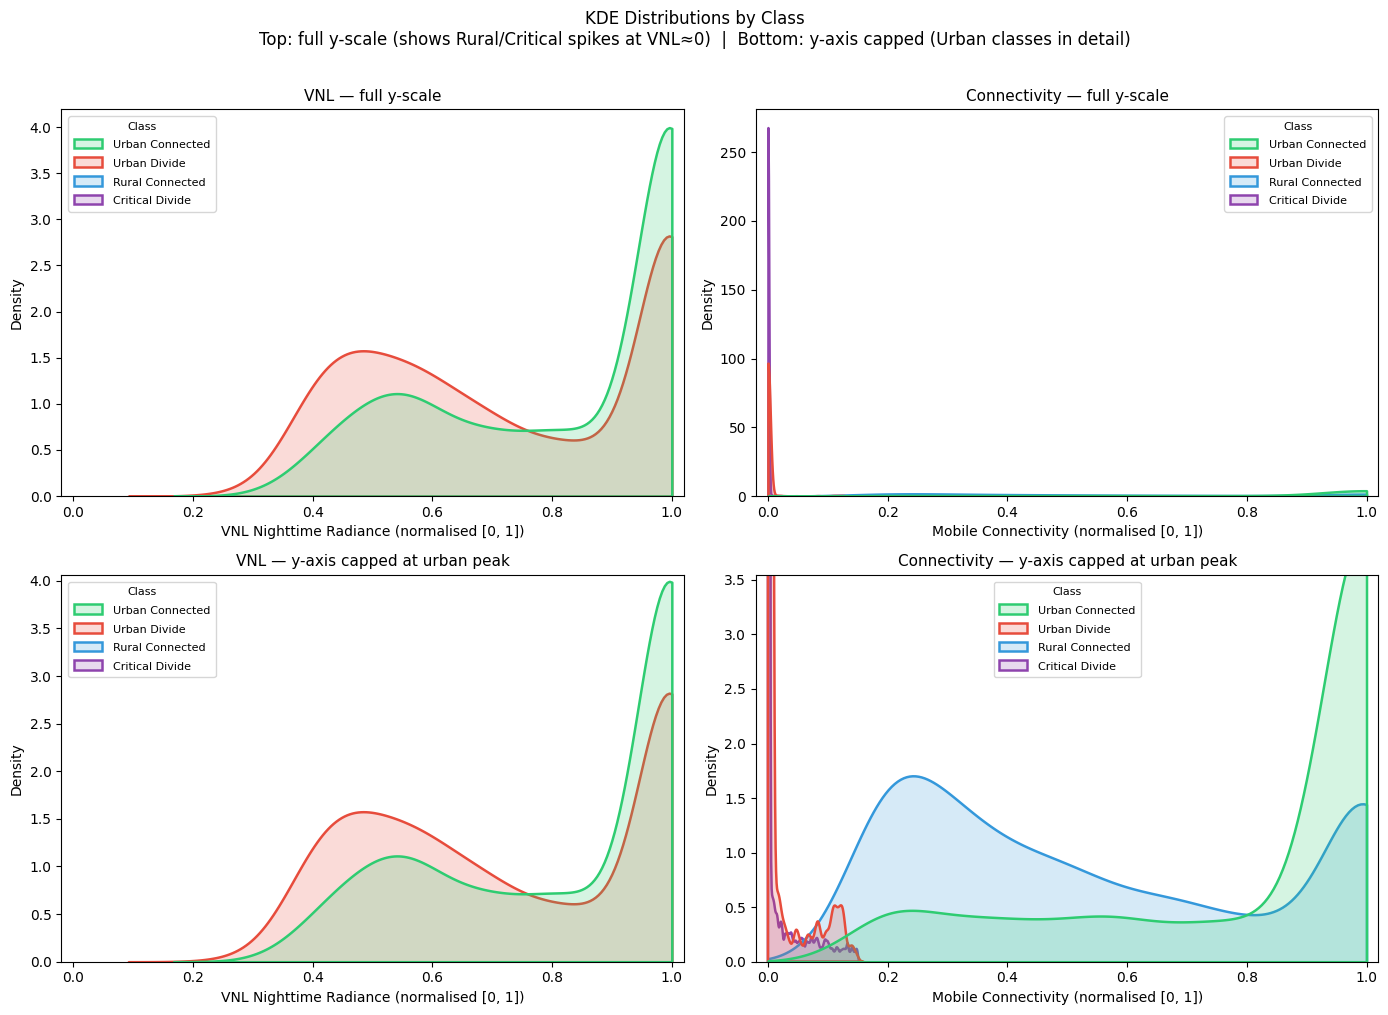

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

CLASS_PALETTE = {
    "Urban Connected": "#2ECC71",
    "Urban Divide":    "#E74C3C",
    "Rural Connected": "#3498DB",
    "Critical Divide": "#8E44AD",
}

# 1-in-20 subsample keeps seaborn KDE fast without distorting the shape
plot_df = flat_df.iloc[::20].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "KDE Distributions by Class\n"
    "Top: full y-scale (shows Rural/Critical spikes at VNL≈0)  |  "
    "Bottom: y-axis capped (Urban classes in detail)",
    fontsize=12, y=1.01,
)

for col_idx, (col, xlabel) in enumerate(zip(
    ["VNL", "Connectivity"],
    ["VNL Nighttime Radiance (normalised [0, 1])",
     "Mobile Connectivity (normalised [0, 1])"],
)):
    for row_idx in range(2):
        ax = axes[row_idx][col_idx]

        sns.kdeplot(
            data=plot_df,
            x=col,
            hue="Class Name",
            hue_order=CLASS_ORDER,
            palette=CLASS_PALETTE,
            fill=True,
            alpha=0.20,
            linewidth=1.8,
            common_norm=False,
            clip=(0, 1),
            ax=ax,
        )

        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Density", fontsize=10)
        ax.set_xlim(-0.02, 1.02)

        legend = ax.get_legend()
        if legend:
            legend.set_title("Class", prop={"size": 8})
            for text in legend.get_texts():
                text.set_fontsize(8)

        if row_idx == 0:
            ax.set_title(f"{'VNL' if col_idx == 0 else 'Connectivity'} — full y-scale",
                         fontsize=11, pad=6)
        else:
            # Cap y-axis at the peak density of the two Urban classes only
            urban_df = plot_df[plot_df["Class Name"].isin(["Urban Connected", "Urban Divide"])]
            from scipy.stats import gaussian_kde
            if len(urban_df) > 1:
                xs = urban_df[col].values
                kde_est = gaussian_kde(xs)
                import numpy as np
                x_grid = np.linspace(0, 1, 500)
                y_peak = kde_est(x_grid).max()
            else:
                y_peak = 5
            ax.set_ylim(0, y_peak * 1.15)
            ax.set_title(f"{'VNL' if col_idx == 0 else 'Connectivity'} — y-axis capped at urban peak",
                         fontsize=11, pad=6)

plt.tight_layout()
plt.show()


In [28]:
from scipy import stats as sp_stats
import numpy as np

vnl_c1 = vnl_norm[clasificacion == 1].astype(np.float64)  # Urban Connected
vnl_c4 = vnl_norm[clasificacion == 4].astype(np.float64)  # Critical Divide

# Welch's t-test (equal_var=False)
t_stat, p_val = sp_stats.ttest_ind(vnl_c1, vnl_c4, equal_var=False)

# Cohen's d (pooled SD, unpaired)
n1, n2 = len(vnl_c1), len(vnl_c4)
pooled_sd = np.sqrt(
    ((n1 - 1) * vnl_c1.std(ddof=1) ** 2 + (n2 - 1) * vnl_c4.std(ddof=1) ** 2)
    / (n1 + n2 - 2)
)
cohens_d = (vnl_c1.mean() - vnl_c4.mean()) / pooled_sd

d_abs = abs(cohens_d)
effect = "small" if d_abs < 0.5 else ("medium" if d_abs < 0.8 else "large")

print("Welch's t-test — VNL: Class 1 (Urban Connected) vs Class 4 (Critical Divide)")
print("=" * 72)
print(f"  {'':30s}  {'Class 1':>14}  {'Class 4':>14}")
print(f"  {'n (pixels)':<30}  {n1:>14,}  {n2:>14,}")
print(f"  {'mean (normalised VNL)':<30}  {vnl_c1.mean():>14.4f}  {vnl_c4.mean():>14.4f}")
print(f"  {'std  (normalised VNL)':<30}  {vnl_c1.std(ddof=1):>14.4f}  {vnl_c4.std(ddof=1):>14.4f}")
print()
print(f"  t-statistic : {t_stat:>12.4f}")
print(f"  p-value     : {p_val:>12.4e}  {'(statistically significant)' if p_val < 0.05 else '(not significant)'}")
print(f"  Cohen's d   : {cohens_d:>12.4f}  ({effect} effect)")


Welch's t-test — VNL: Class 1 (Urban Connected) vs Class 4 (Critical Divide)
                                         Class 1         Class 4
  n (pixels)                              17,521         943,710
  mean (normalised VNL)                   0.8318          0.0000
  std  (normalised VNL)                   0.2067          0.0004

  t-statistic :     532.6509
  p-value     :   0.0000e+00  (statistically significant)
  Cohen's d   :      29.8038  (large effect)


In [29]:
# --- Export the four processed rasters to output/ ---
import numpy as np
import rasterio

def _save_f32(arr, path, base_profile, nodata=-9999.0):
    prof = base_profile.copy()
    prof.update(dtype=rasterio.float32, count=1, nodata=nodata, compress="lzw")
    with rasterio.open(path, "w", **prof) as dst:
        dst.write(arr.astype(np.float32), 1)
    return path.stat().st_size / 1024

with rasterio.open(vnl_path) as src:
    base_profile = src.profile.copy()

OUTPUT_DIR.mkdir(exist_ok=True)

exports = [
    (vnl_norm,     OUTPUT_DIR / "vnl_norm.tif",            "float32", "Normalised nighttime lights"),
    (kde_norm,     OUTPUT_DIR / "conn_norm.tif",           "float32", "Normalised mobile connectivity"),
    (ibd,          OUTPUT_DIR / "ibd_brecha_digital.tif",  "float32", "Digital Divide Index (IBD)"),
]

print(f"{"": <35} {"Shape":>10}  {"Type":>7}  {"KB":>8}  Description")
print("-" * 80)
for arr, path, dtype, desc in exports:
    kb = _save_f32(arr, path, base_profile)
    print(f"  {path.name:<33} {str(arr.shape):>10}  {dtype:>7}  {kb:>7.1f}  {desc}")

# classification (uint8) — keep consistent with previous save
cls_path = OUTPUT_DIR / "clasificacion_brecha.tif"
cls_prof = base_profile.copy()
cls_prof.update(dtype=rasterio.uint8, count=1, nodata=0, compress="lzw")
with rasterio.open(cls_path, "w", **cls_prof) as dst:
    dst.write(clasificacion, 1)
kb_cls = cls_path.stat().st_size / 1024
print(f"  {cls_path.name:<33} {str(clasificacion.shape):>10}  {"uint8":>7}  {kb_cls:>7.1f}  2×2 classification")
print("-" * 80)
print("All rasters saved to output/")


                                         Shape     Type        KB  Description
--------------------------------------------------------------------------------
  vnl_norm.tif                      (1081, 961)  float32    239.0  Normalised nighttime lights
  conn_norm.tif                     (1081, 961)  float32    476.8  Normalised mobile connectivity
  ibd_brecha_digital.tif            (1081, 961)  float32    616.9  Digital Divide Index (IBD)
  clasificacion_brecha.tif          (1081, 961)    uint8     68.0  2×2 classification
--------------------------------------------------------------------------------
All rasters saved to output/


Dashboard saved → /Users/macbookair/Documents/GitHub/raster-digital-divide/output/dashboard_brecha_digital.png
Size            : 495.3 KB


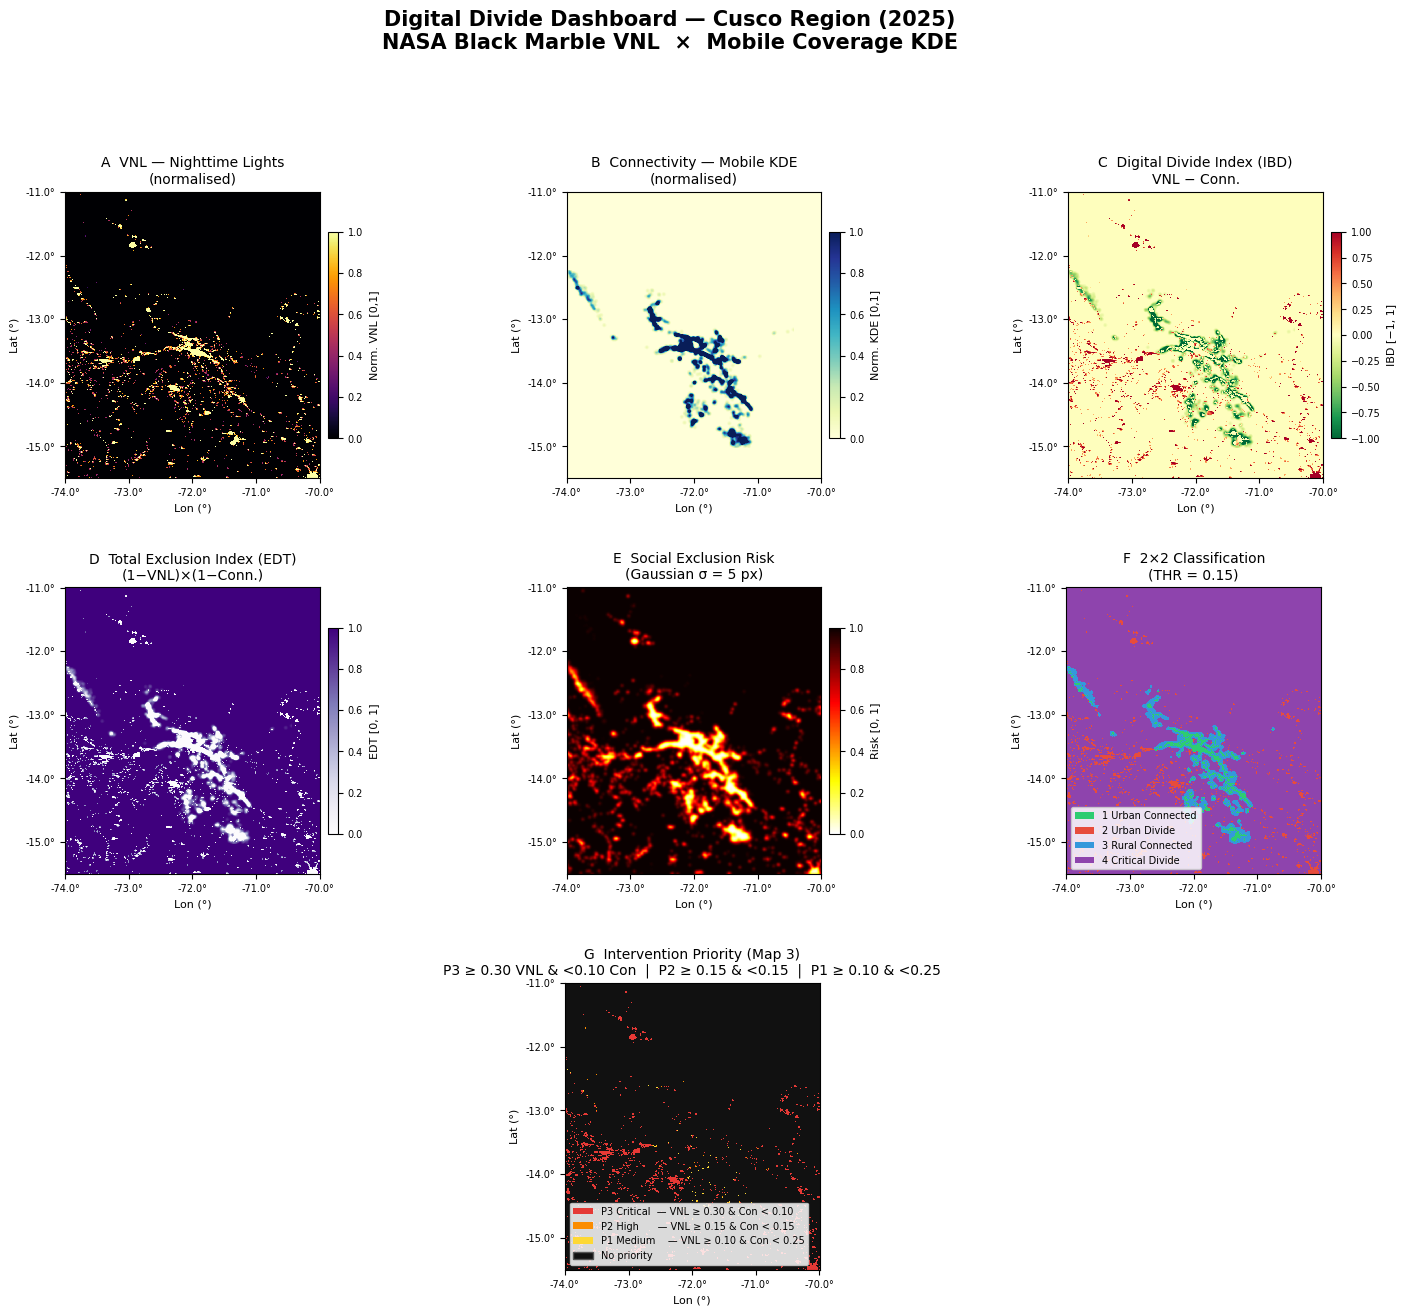

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap, BoundaryNorm

# ── Colormaps ────────────────────────────────────────────────────────────────
cmap_cls2  = ListedColormap(["#2ECC71", "#E74C3C", "#3498DB", "#8E44AD"])
bnorm_cls  = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap_cls2.N)

cmap_prio  = ListedColormap(["#111111", "#FDD835", "#FB8C00", "#E53935"])
bnorm_prio = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_prio.N)

# ── 7-panel mosaic layout ────────────────────────────────────────────────────
mosaic = [["A", "B", "C"],
          ["D", "E", "F"],
          [".", "G", "."]]

fig, axd = plt.subplot_mosaic(
    mosaic,
    figsize=(18, 14),
    gridspec_kw={"hspace": 0.38, "wspace": 0.28},
)

fig.suptitle(
    "Digital Divide Dashboard — Cusco Region (2025)\n"
    "NASA Black Marble VNL  ×  Mobile Coverage KDE",
    fontsize=15, fontweight="bold", y=1.01,
)

# ── Panel definitions ─────────────────────────────────────────────────────────
panels = [
    ("A", vnl_norm,      "A  VNL — Nighttime Lights\n(normalised)",
     "inferno",    0,  1,  "Norm. VNL [0,1]",  None),
    ("B", kde_norm,      "B  Connectivity — Mobile KDE\n(normalised)",
     "YlGnBu",     0,  1,  "Norm. KDE [0,1]",  None),
    ("C", ibd,           "C  Digital Divide Index (IBD)\nVNL − Conn.",
     "RdYlGn_r",  -1,  1,  "IBD [−1, 1]",      None),
    ("D", edt,           "D  Total Exclusion Index (EDT)\n(1−VNL)×(1−Conn.)",
     "Purples",    0,  1,  "EDT [0, 1]",        None),
    ("E", risk_smooth,   "E  Social Exclusion Risk\n(Gaussian σ = 5 px)",
     "hot_r",      0,  1,  "Risk [0, 1]",       None),
    ("F", clasificacion, "F  2×2 Classification\n(THR = 0.15)",
     None, None, None, None,                                  "cls"),
    ("G", priority,      "G  Intervention Priority (Map 3)\n"
                         "P3 ≥ 0.30 VNL & <0.10 Con  |  P2 ≥ 0.15 & <0.15  |  P1 ≥ 0.10 & <0.25",
     None, None, None, None,                                  "prio"),
]

for key, arr, title, cmap, vmin, vmax, cbar_label, special in panels:
    ax = axd[key]

    if special == "cls":
        ax.imshow(arr, cmap=cmap_cls2, norm=bnorm_cls,
                  extent=extent_geo, origin="upper", interpolation="none")
        ax.legend(handles=[
            mpatches.Patch(facecolor="#2ECC71", label="1 Urban Connected"),
            mpatches.Patch(facecolor="#E74C3C", label="2 Urban Divide"),
            mpatches.Patch(facecolor="#3498DB", label="3 Rural Connected"),
            mpatches.Patch(facecolor="#8E44AD", label="4 Critical Divide"),
        ], loc="lower left", fontsize=7, framealpha=0.85)

    elif special == "prio":
        ax.imshow(arr, cmap=cmap_prio, norm=bnorm_prio,
                  extent=extent_geo, origin="upper", interpolation="none")
        ax.legend(handles=[
            mpatches.Patch(facecolor="#E53935", label="P3 Critical  — VNL ≥ 0.30 & Con < 0.10"),
            mpatches.Patch(facecolor="#FB8C00", label="P2 High      — VNL ≥ 0.15 & Con < 0.15"),
            mpatches.Patch(facecolor="#FDD835", label="P1 Medium    — VNL ≥ 0.10 & Con < 0.25"),
            mpatches.Patch(facecolor="#111111", edgecolor="#555", label="No priority"),
        ], loc="lower left", fontsize=7, framealpha=0.85)

    else:
        im = ax.imshow(arr, cmap=cmap, extent=extent_geo, origin="upper",
                       vmin=vmin, vmax=vmax, interpolation="none")
        cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
        cb.set_label(cbar_label, fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xlabel("Lon (°)", fontsize=8)
    ax.set_ylabel("Lat (°)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f°"))

out_png = OUTPUT_DIR / "dashboard_brecha_digital.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
print(f"Dashboard saved → {out_png.resolve()}")
print(f"Size            : {out_png.stat().st_size / 1024:.1f} KB")
plt.show()
